# Model 1: InceptionResNetV2 — Siamese Multimodal Network

**Kiến trúc:**
```
InceptionResNetV2 (shared, pretrained ImageNet) → GAP
    → Linear(feat_dim, 128) + ReLU + Dropout(0.4)   # per eye

[left_128D | right_128D] → 256-D image feature
[age_norm, gender_M, gender_F] → Linear(3, 16) + ReLU → 16-D

[256-D | 16-D] = 272-D
    → Linear(272, 64) + ReLU + Dropout(0.4)
    → Linear(64, 8)   ← logits (BCEWithLogitsLoss)
```

**Loss**: BCEWithLogitsLoss với pos_weight (class imbalance)  
**Optimizer**: Adam + ReduceLROnPlateau

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version (built with):", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Compute capability:", torch.cuda.get_device_capability(0))

PyTorch version: 2.10.0+cu128
CUDA version (built with): 12.8
GPU: Tesla T4
Compute capability: (7, 5)


In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# ===== CẤU HÌNH =====
PREPROC_DIR  = f'/kaggle/input/datasets/xuanductran/odir-data-preprocess-augmentation/odir-data-preprocess-augmentation'
MODEL_DIR    = f'/kaggle/working'
CHECKPT_DIR  = f'{MODEL_DIR}/checkpoints'
HISTORY_DIR  = f'{MODEL_DIR}/history'
os.makedirs(CHECKPT_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

TARGET_COLS   = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
BACKBONE      = 'inception_resnet_v2'
BACKBONE_TAG  = 'inceptionresnet'   # dùng đặt tên file
IMAGE_SIZE    = 299
BATCH_SIZE    = 16      # giảm xuống 8 nếu OOM
NUM_EPOCHS    = 50
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
DROPOUT       = 0.4
PROJ_DIM      = 128
TABULAR_DIM   = 16
NUM_WORKERS   = 4
PATIENCE      = 8       # early stopping patience

print(f'Backbone: {BACKBONE}, Image size: {IMAGE_SIZE}x{IMAGE_SIZE}, Batch: {BATCH_SIZE}')

Backbone: inception_resnet_v2, Image size: 299x299, Batch: 16


## 1. Load dữ liệu

In [4]:
meta_df = pd.read_csv(f'{PREPROC_DIR}/split_metadata.csv')
OLD_PREFIX = '/home/centrala/work/ou/kltn/Ocular-Disease-Recognition/odir-data-preprocess-augmentation'

meta_df['left_path']  = meta_df['left_path'].str.replace(OLD_PREFIX, PREPROC_DIR, regex=False)
meta_df['right_path'] = meta_df['right_path'].str.replace(OLD_PREFIX, PREPROC_DIR, regex=False)
with open(f'{PREPROC_DIR}/class_weights.json') as f:
    class_weights_dict = json.load(f)

pos_weight = torch.tensor(
    [class_weights_dict[c] for c in TARGET_COLS],
    dtype=torch.float32
).to(device)

train_df = meta_df[meta_df['split'] == 'train'].reset_index(drop=True)
val_df   = meta_df[(meta_df['split'] == 'val') & (meta_df['aug_id'] == -1)].reset_index(drop=True)

print(f'Train rows (incl. augmented): {len(train_df)}')
print(f'Val rows (base only):         {len(val_df)}')
print(f'Class weights: {class_weights_dict}')

Train rows (incl. augmented): 17171
Val rows (base only):         697
Class weights: {'N': 2.0739, 'D': 2.109, 'G': 15.245, 'C': 15.4631, 'A': 20.3304, 'H': 33.0694, 'M': 19.1066, 'O': 2.581}


In [5]:
# Chuẩn hóa tuổi: Z-score từ base train
train_base_df = meta_df[(meta_df['split'] == 'train') & (meta_df['aug_id'] == -1)]
AGE_MEAN = float(train_base_df['age'].mean())
AGE_STD  = float(train_base_df['age'].std())

norm_params = {'age_mean': AGE_MEAN, 'age_std': AGE_STD}
with open(f'{MODEL_DIR}/norm_params.json', 'w') as f:
    json.dump(norm_params, f, indent=2)
print(f'Age normalization — mean: {AGE_MEAN:.2f}, std: {AGE_STD:.2f}')
print(f'Saved: {MODEL_DIR}/norm_params.json')


def encode_gender(gender_str):
    """[1, 0] = Male, [0, 1] = Female"""
    s = str(gender_str).strip().lower()
    if s in ('male', 'm'):
        return [1.0, 0.0]
    return [0.0, 1.0]

Age normalization — mean: 57.82, std: 11.77
Saved: /kaggle/working/norm_params.json


## 2. Dataset và DataLoader

In [6]:
class OdirDataset(Dataset):
    """
    Load ảnh đã tiền xử lý (Graham + resize) từ đĩa.
    Chỉ normalize theo ImageNet stats ở đây.
    """
    def __init__(self, df, target_cols, image_size, age_mean, age_std):
        self.df          = df.reset_index(drop=True)
        self.target_cols = target_cols
        self.age_mean    = age_mean
        self.age_std     = age_std
        self.transform   = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        left_img  = Image.open(row['left_path']).convert('RGB')
        right_img = Image.open(row['right_path']).convert('RGB')
        left_t    = self.transform(left_img)
        right_t   = self.transform(right_img)

        age_norm  = (row['age'] - self.age_mean) / (self.age_std + 1e-8)
        gender    = encode_gender(row['gender'])
        tabular   = torch.tensor([age_norm] + gender, dtype=torch.float32)

        labels    = torch.tensor([float(row[c]) for c in self.target_cols],
                                  dtype=torch.float32)
        return left_t, right_t, tabular, labels


train_dataset = OdirDataset(train_df, TARGET_COLS, IMAGE_SIZE, AGE_MEAN, AGE_STD)
val_dataset   = OdirDataset(val_df,   TARGET_COLS, IMAGE_SIZE, AGE_MEAN, AGE_STD)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 1074 | Val batches: 44


## 3. Kiến trúc mô hình

In [7]:
class SiameseMultimodalNet(nn.Module):
    """
    Multimodal Dual-Eye Siamese Network.

    Backbone (shared weights) xử lý ảnh mắt trái và mắt phải độc lập,
    sau đó kết hợp với đặc trưng nhân khẩu học (tuổi + giới tính).

    Output: logits (8 chiều). Áp dụng sigmoid() khi inference.
    Dùng BCEWithLogitsLoss khi training để ổn định số học.
    """
    def __init__(self, backbone_name, proj_dim=128, tabular_dim=16,
                 dropout=0.4, num_classes=8):
        super().__init__()
        self.backbone  = timm.create_model(backbone_name, pretrained=True,
                                           num_classes=0, global_pool='avg')
        feat_dim       = self.backbone.num_features

        self.projector = nn.Sequential(
            nn.Linear(feat_dim, proj_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        self.tabular_encoder = nn.Sequential(
            nn.Linear(3, tabular_dim),
            nn.ReLU(inplace=True)
        )
        fused_dim    = 2 * proj_dim + tabular_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward_one(self, x):
        return self.projector(self.backbone(x))

    def forward(self, left, right, tabular):
        img_feat = torch.cat([self.forward_one(left),
                               self.forward_one(right)], dim=1)
        tab_feat = self.tabular_encoder(tabular)
        fused    = torch.cat([img_feat, tab_feat], dim=1)
        return self.classifier(fused)


# Kiểm tra backbone khả dụng
available = timm.list_models(f'*{BACKBONE_TAG}*', pretrained=True)
print(f'Available {BACKBONE_TAG} models: {available[:5]}')

model = SiameseMultimodalNet(
    backbone_name=BACKBONE,
    proj_dim=PROJ_DIM,
    tabular_dim=TABULAR_DIM,
    dropout=DROPOUT,
    num_classes=len(TARGET_COLS)
).to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Available inceptionresnet models: []


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

Total parameters:     54,521,256
Trainable parameters: 54,521,256


## 4. Loss, Optimizer, Scheduler

In [8]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
print('Loss: BCEWithLogitsLoss với pos_weight')
print(f'Optimizer: Adam (lr={LR}, wd={WEIGHT_DECAY})')

Loss: BCEWithLogitsLoss với pos_weight
Optimizer: Adam (lr=0.0001, wd=0.0001)


## 5. Hàm Train và Validate

In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_logits, all_labels = [], []

    for left, right, tabular, labels in loader:
        left, right, tabular, labels = (
            left.to(device), right.to(device),
            tabular.to(device), labels.to(device)
        )
        optimizer.zero_grad()
        logits = model(left, right, tabular)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.cpu())

    avg_loss   = total_loss / len(loader)
    all_probs  = torch.sigmoid(torch.cat(all_logits)).numpy()
    all_labels = torch.cat(all_labels).numpy()
    try:
        auc = roc_auc_score(all_labels, all_probs, average='macro')
    except Exception:
        auc = 0.0
    return avg_loss, auc


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []

    with torch.no_grad():
        for left, right, tabular, labels in loader:
            left, right, tabular, labels = (
                left.to(device), right.to(device),
                tabular.to(device), labels.to(device)
            )
            logits = model(left, right, tabular)
            loss   = criterion(logits, labels)
            total_loss += loss.item()
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    avg_loss   = total_loss / len(loader)
    all_probs  = torch.sigmoid(torch.cat(all_logits)).numpy()
    all_labels = torch.cat(all_labels).numpy()
    try:
        auc = roc_auc_score(all_labels, all_probs, average='macro')
    except Exception:
        auc = 0.0
    return avg_loss, auc


print('Hàm training và validation OK')

Hàm training và validation OK


## 6. Training Loop

In [10]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_auc': [], 'val_auc': [],
    'lr': []
}
best_val_loss    = float('inf')
patience_counter = 0
checkpoint_path  = f'{CHECKPT_DIR}/{BACKBONE_TAG}_best.pth'

print(f'Bắt đầu training: {NUM_EPOCHS} epochs')
print(f'Checkpoint: {checkpoint_path}')
print('-' * 90)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_auc   = validate_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Train Loss={train_loss:.4f} AUC={train_auc:.4f} | '
          f'Val Loss={val_loss:.4f} AUC={val_auc:.4f} | '
          f'LR={current_lr:.2e} | {elapsed:.0f}s')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch':                 epoch,
            'model_state_dict':      model.state_dict(),
            'optimizer_state_dict':  optimizer.state_dict(),
            'val_loss':              val_loss,
            'val_auc':               val_auc,
            'backbone':              BACKBONE,
            'config': {
                'image_size': IMAGE_SIZE, 'proj_dim': PROJ_DIM,
                'tabular_dim': TABULAR_DIM, 'dropout': DROPOUT
            }
        }, checkpoint_path)
        print(f'  *** Best checkpoint saved (val_loss={val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping sau {epoch} epochs (patience={PATIENCE})')
            break

print(f'\nBest val_loss: {best_val_loss:.4f}')

Bắt đầu training: 50 epochs
Checkpoint: /kaggle/working/checkpoints/inceptionresnet_best.pth
------------------------------------------------------------------------------------------
Epoch   1/50 | Train Loss=0.8992 AUC=0.7436 | Val Loss=0.7775 AUC=0.8235 | LR=1.00e-04 | 1408s
  *** Best checkpoint saved (val_loss=0.7775)
Epoch   2/50 | Train Loss=0.6264 AUC=0.8478 | Val Loss=0.7827 AUC=0.8433 | LR=1.00e-04 | 1404s
Epoch   3/50 | Train Loss=0.5031 AUC=0.8798 | Val Loss=0.8672 AUC=0.8349 | LR=1.00e-04 | 1403s
Epoch   4/50 | Train Loss=0.4294 AUC=0.9020 | Val Loss=0.9481 AUC=0.8327 | LR=1.00e-04 | 1402s
Epoch   5/50 | Train Loss=0.3750 AUC=0.9225 | Val Loss=1.0270 AUC=0.8486 | LR=1.00e-04 | 1401s
Epoch   6/50 | Train Loss=0.3207 AUC=0.9396 | Val Loss=1.0065 AUC=0.8449 | LR=1.00e-04 | 1400s
Epoch   7/50 | Train Loss=0.2842 AUC=0.9499 | Val Loss=1.4191 AUC=0.8436 | LR=5.00e-05 | 1401s
Epoch   8/50 | Train Loss=0.2217 AUC=0.9631 | Val Loss=1.5915 AUC=0.8429 | LR=5.00e-05 | 1405s
Epoch   9/

## 7. Lưu lịch sử và vẽ đồ thị

Saved: /kaggle/working/history/inceptionresnet_history.json


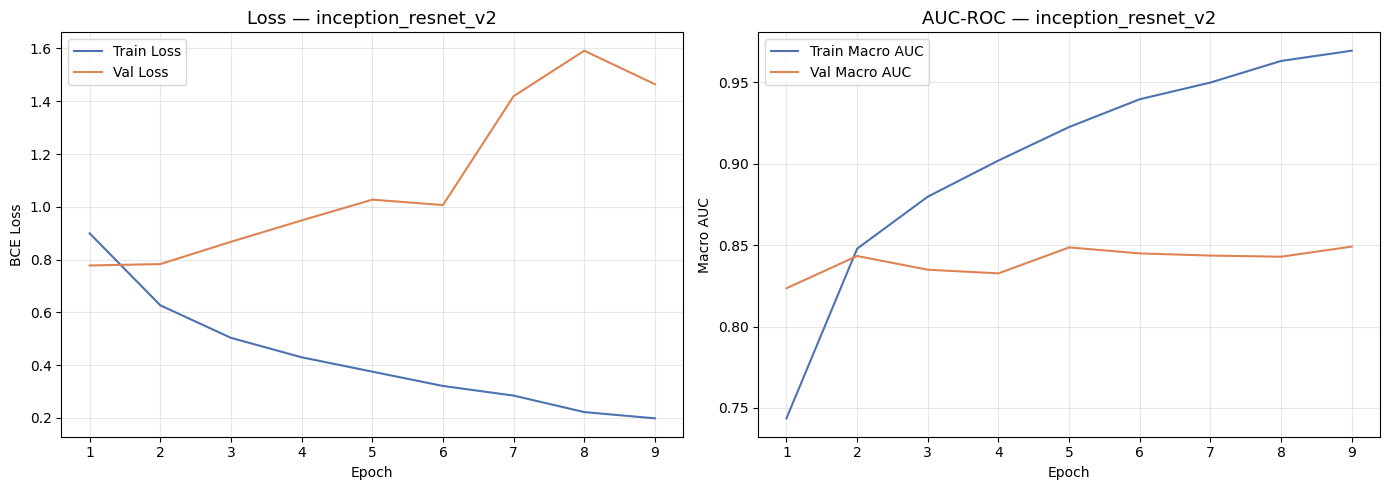

Saved: /kaggle/working/chart_inceptionresnet_history.png


In [11]:
history_path = f'{HISTORY_DIR}/{BACKBONE_TAG}_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'Saved: {history_path}')

epochs = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history['train_loss'], label='Train Loss', color='#4C72B0')
ax1.plot(epochs, history['val_loss'],   label='Val Loss',   color='#DD8452')
ax1.set_title(f'Loss — {BACKBONE}', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_auc'], label='Train Macro AUC', color='#4C72B0')
ax2.plot(epochs, history['val_auc'],   label='Val Macro AUC',   color='#DD8452')
ax2.set_title(f'AUC-ROC — {BACKBONE}', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro AUC')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
chart_path = f'{MODEL_DIR}/chart_{BACKBONE_TAG}_history.png'
plt.savefig(chart_path, dpi=120)
plt.show()
print(f'Saved: {chart_path}')

## Tóm tắt

**Outputs:**
- `model_v2/checkpoints/inceptionresnet_best.pth`
- `model_v2/history/inceptionresnet_history.json`
- `model_v2/norm_params.json`
- `model_v2/chart_inceptionresnet_history.png`

**Bước tiếp theo:** Chạy `04_model_xception.ipynb`